<table>
<tr>
    <td width=10%><img src="./img/logo_lri.jpg"></td>
    <td width=30%><img src="./img/medi-chal_logo.png" height=15%></img></td>
</tr>

</table>

<br/><br/><div id="top"></div>

<center><a style="font-size: 40pt; font-weight: bold">
    Être ou ne pas être ?
</a></center>
<br/>
<center><a style="font-size: 22pt; font-weight: bold">
    Un problème de classification binaire sur des données médicales artificelles
<br/>

---

# Membres du groupe

**Minimum 2, Maximum 3**

<span style="color:red">
    Répondre ci-dessous
</span>

AROUG Amine 

# Présentation du challenge

## La question principale de ce challenge est : 

* Comment prédire la survie d'un·e patient·e compte tenu de son dossier médical ? 
    
* Plus précisément, vous devrez prédire la survie des patient·e·s pendant leur séjour à l'hôpital
 
Chaque jour, le personnel soignant collecte de nombreuses informations sur les patient·e·s en posant des questions et en utilisant des outils de mesure (stéthoscope, analyse de sang, capteurs, etc.). Ces données sont très utiles pour surveiller l'état de santé, diagnostiquer et choisir les traitements.

Elles peuvent également être utilisées pour l'analyse statistique prédictive.

## Données

L'ensemble de données contient des informations sur 80'000 patient·e·s, représentés par des variables (descripteurs) catégorielles, binaires et numériques. Ces variables sont, par exemple, l'âge, le sexe, l'origine ethnique, l'état matrimonial, ainsi que des données médicales telles que la tension artérielle ou le taux de glucose. Il y a un total de 342 variables.

La classe (étiquette ou label) à prédire est une variable binaire indiquant si la·le patient·e est décédé·e ou non pendant son séjour à l'hôpital. Heureusement, la plupart survivent :

![](img/tobe.png)

## Tâche

La tâche consiste à créer un modèle capable d'apprendre à partir des données et de faire des prédictions (apprentissage supervisé). Chaque instance (patient·e) possède une variable indiquant si elle·il est décédé·e ou non pendant son séjour à l'hôpital.

Références et crédit :

Isabelle Guyon, Kristin Bennett, Andrew Yale, Adrien Pavao, Thomas Gerspacher

## Instructions

Le but de ce TP est de travailler sur un challenge de prédiction de la mortalité.

Le lien vers le challenge :
https://codalab.lisn.upsaclay.fr/competitions/12130

* **Étape 1 :** S'enregistrer sur https://codalab.lisn.upsaclay.fr

* **Étape 2:** Téléchargez le jeu de données à partir de la [page](https://codalab.lisn.upsaclay.fr/competitions/12130#participate-get_starting_kit) "Participate > Files > Public Data".

* **Étape 3:** Parcourez ce notebook. Vous devrez lire, exécuter, **coder vos propres méthodes** et **répondre aux questions**. Utilisez la cellule ***code*** pour le codage et la cellule ***markdown*** pour répondre aux questions.

## Évaluation du projet

* **4 points** pour la partie compréhension et analyse exploratoire
    
* **4 points** pour un code propre et bien documenté

* **4 points** pour la qualité du modèle (sélection du modèle, sélection des hyperparamètres)

* **4 points** pour une bonne évaluation des performances du modèle

* **4 points** pour la qualité de la présentation orale 

* **1 point bonus** pour l'équipe gagnante du challenge

### FAQ

* Soumettre uniquement le notebook sur eCampus

* La partie texte (explications, résultats, problèmes, sans le code) ne doit pas dépasser 3 pages A4 11pt (< 1500 mots)

# Challenge

Module requis : `imblearn` (à installer avec `conda`)

`conda install -c conda-forge imbalanced-learn`

In [ ]:
%pip install imbalanced-learn

In [ ]:
%pip install matplotlib seaborn

In [1]:
import platform
from datetime import datetime
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn import (
    decomposition,
    discriminant_analysis,
    ensemble,
    linear_model,
    metrics,
    model_selection,
    naive_bayes,
    pipeline,
    preprocessing,
    svm,
)

In [2]:
if platform.system() == "Darwin":
    %config InlineBackend.figure_format="retina"  # For high DPI display

# Set precision for pd and np (np: suppress also sci notation)
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:,.3g}".format

sns.set_style("darkgrid")
sns.set_context("notebook")

print(pd.__version__)       # 2.0.0
print(sklearn.__version__)  # 1.2.2

2.3.3
1.6.1


## 1. Compréhension du problème

### Expliquez brièvement la tâche avec vos mots

<span style="color:red">
    Répondre ci-dessous
</span>

A l'aide des données récuperé nous devrons etre capable de predire le pourcentage de chance de vie d'un patient.

### Métrique utilisée

Pourquoi la métrique utilisée ici est la [`sklearn.metrics.balanced_accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html) plutôt que simplement l'[`sklearn.metrics.accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) ?

<span style="color:red">
    Répondre ci-dessous
</span>

Déséquilibre des classes : Le jeu de données est fortement déséquilibré : la moyenne de la variable cible est de 0.035, ce qui signifie que seulement 3,5% des patients sont décédés.

Éviter le score trompeur : Avec l'accuracy_score classique, un modèle qui prédirait systématiquement "Survie" pour tout le monde obtiendrait 96,5% de bonnes réponses tout en étant incapable de détecter le moindre décès.

Équité de mesure : La balanced_accuracy_score calcule la moyenne des taux de réussite (rappel) pour chaque classe. Elle donne autant d'importance à la détection des décès (classe minoritaire) qu'à celle des survivants (classe majoritaire), offrant ainsi une évaluation plus juste de la performance réelle du modèle sur ce type de données médicales.

## 2. Chargement des données

In [3]:
DATA = Path(
    "/Users/aamine/Desktop/Computer Sciences/ToutMesProjets/ProjetISD/data/public_dat"
).expanduser()
# DATA = Path("public_data")

PRED_PATH = Path("Submissions")

DROP_VARS = ["ADMITTIME", "DISCHTIME", "SUBJECT_ID", "HADM_ID"]

assert DATA.is_dir()

In [4]:
features = pd.read_csv(
    DATA / "mimic_synthetic_feat.name", header=None
).values.flatten()

labels = pd.read_csv(
    DATA / "mimic_synthetic_label.name", header=None
).values.flatten()

x_df = pd.read_csv(
    DATA / "mimic_synthetic_train.data",
    header=None,
    names=features,
    sep=" ",
)

# Remove variables that are not relevant
x_df.drop(columns=DROP_VARS, inplace=True)

ys = pd.Series(
    pd.read_csv(
        DATA / "mimic_synthetic_train.solution",
        header=None,
        names=labels,
        sep=" ",
    ).values.flatten()
)

In [5]:
print(x_df.shape)
x_df.head(3)

(79999, 337)


,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


C'est **l'ensemble d'entrainement**. Cela signifie que vous avez accès aux étiquettes et que vous pouvez l'utiliser comme vous le souhaitez pour préparer votre modèle.

Plus tard, vous ferez en sorte que votre modèle tire des prédictions de **l'ensemble de test** afin de les téléverser sur Codalab et d'obtenir un score sur des données non vues lors de l'entrainement des modèles.

In [6]:
# Load test set
x_test_df = pd.read_csv(
    DATA / "mimic_synthetic_test.data",
    header=None,
    names=features,
    sep=" ",
)

# Remove variables that are not relevant
x_test_df.drop(columns=DROP_VARS, inplace=True)

print(x_test_df.shape)
x_test_df.head(3)

(20001, 337)


,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Self_Pay,ENGL,OTHER,MARRIED,WHITE,F,18,72.6,113,96.5,...,0,0,0,0,0,0,0,0,0,0
1,Medicare,ENGL,NOT_SPECIFIED,SINGLE,BLACK/AFRICAN_AMERICAN,F,56,66.6,107,83.8,...,0,0,0,0,0,0,0,0,1,0
2,Medicaid,ENGL,CATHOLIC,SINGLE,WHITE,M,32,69.7,103,87.3,...,0,0,0,0,0,0,0,0,0,0


## 3. Analyse exploratoire

#### Types des variables

In [7]:
types = pd.read_csv(DATA / "mimic_synthetic_feat.type", header=None).set_index(
    features
)[0]

types.value_counts()

0
Numerical      226
Binary         107
Categorical      8
Name: count, dtype: int64

#### Distribution de la variable cible

In [8]:
ys.describe()

count   8e+04
mean    0.035
std     0.184
min         0
25%         0
50%         0
75%         0
max         1
dtype: float64

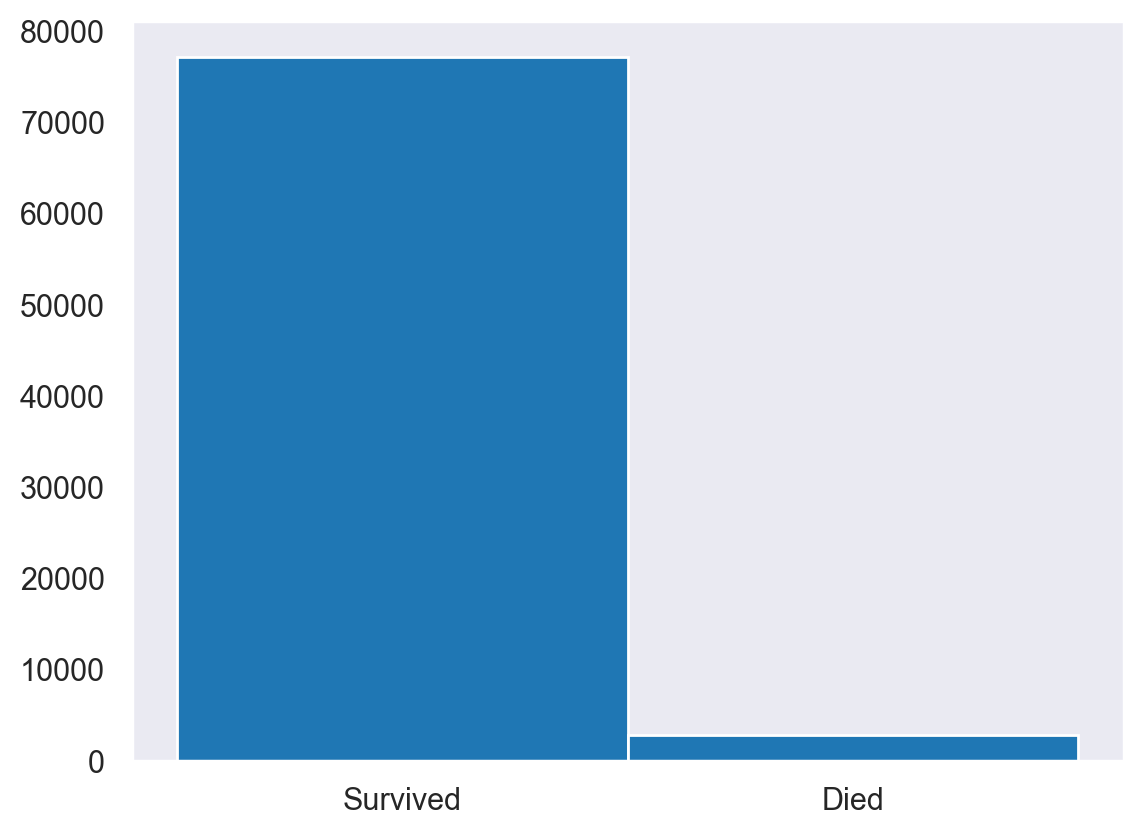

In [9]:
ys.hist(bins=2, grid=False, align="left")
plt.xticks([0, 0.5], ["Survived", "Died"])
# plt.savefig("img/tobe.png", dpi=300)
plt.show()

### Code : Produire les graphiques suivants

* Diagrammes à barres de certaines variables catégorielles (par exemple "LANGUAGE", "MARITAL_STATUS")

* Montrez la corrélation entre certaines variables et la variable cible y

* Un autre graphique ou toute analyse exploratoire à laquelle vous pouvez penser

Exemple

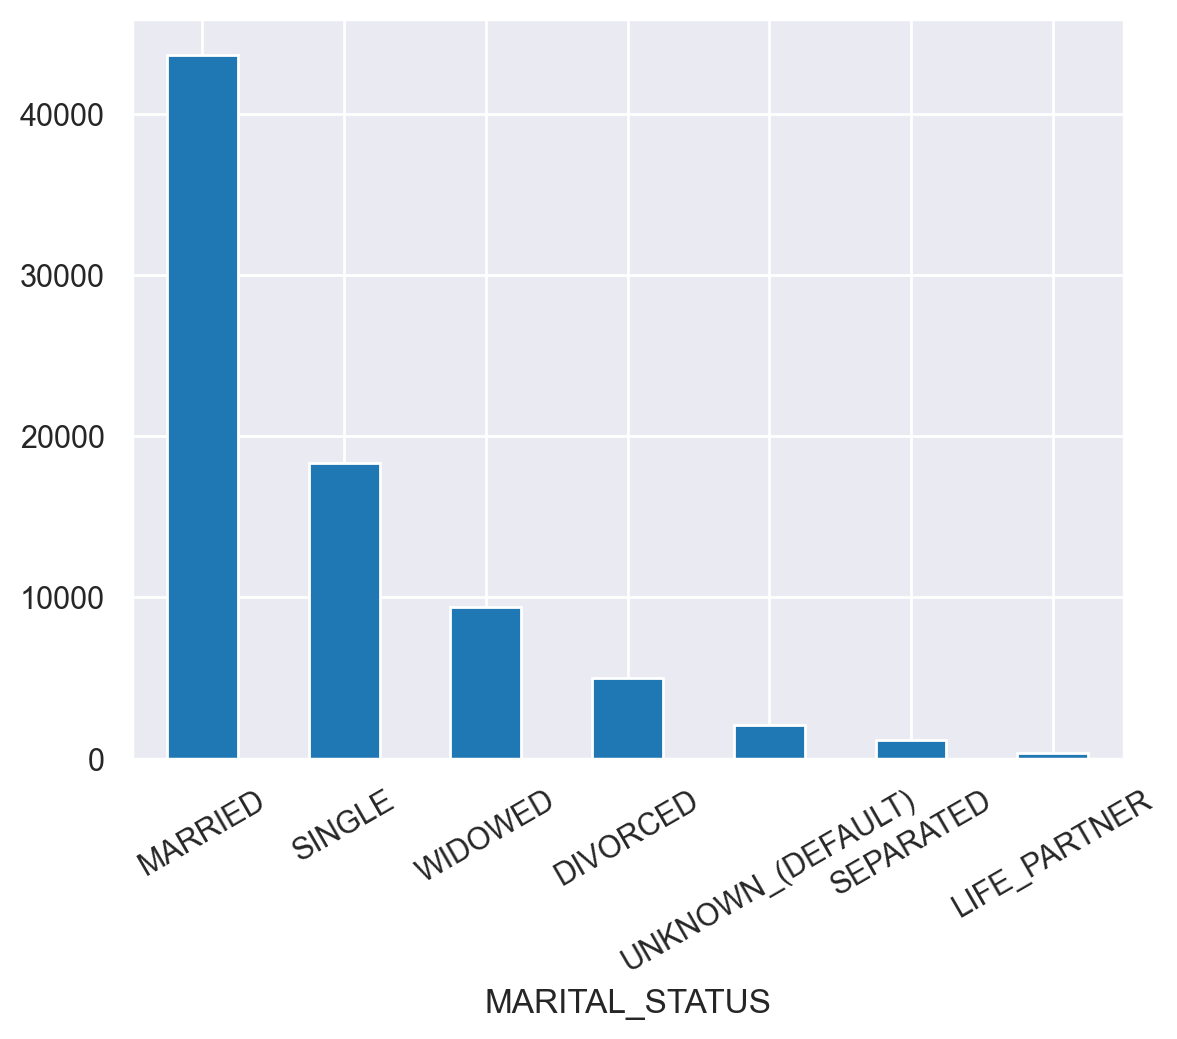

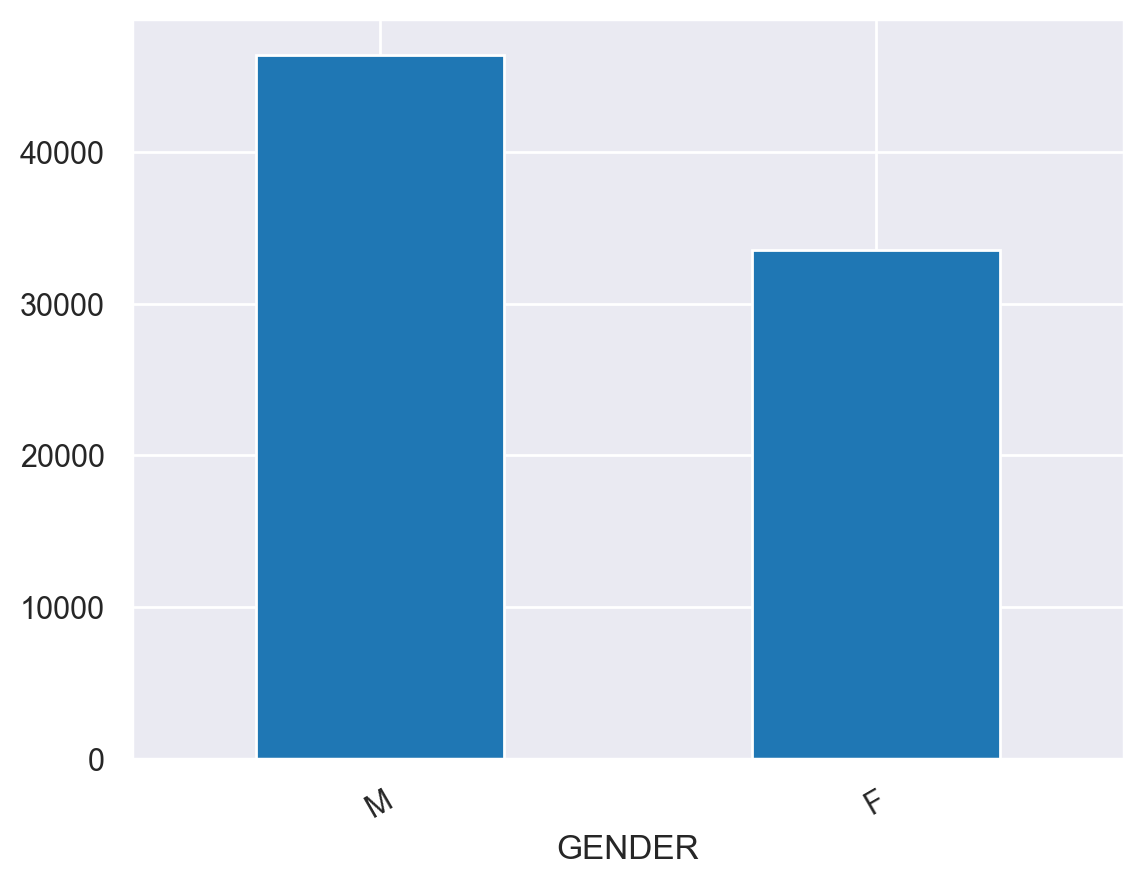

In [16]:
x_marital_cnts = x_df["MARITAL_STATUS"].value_counts()
x_marital_cnts.plot.bar(rot=30)
plt.show()

x_gender_cnts = x_df["GENDER"].value_counts()
x_gender_cnts.plot.bar(rot=30)
plt.show() 

<span style="color:red">
    Répondre ci-dessous
</span>

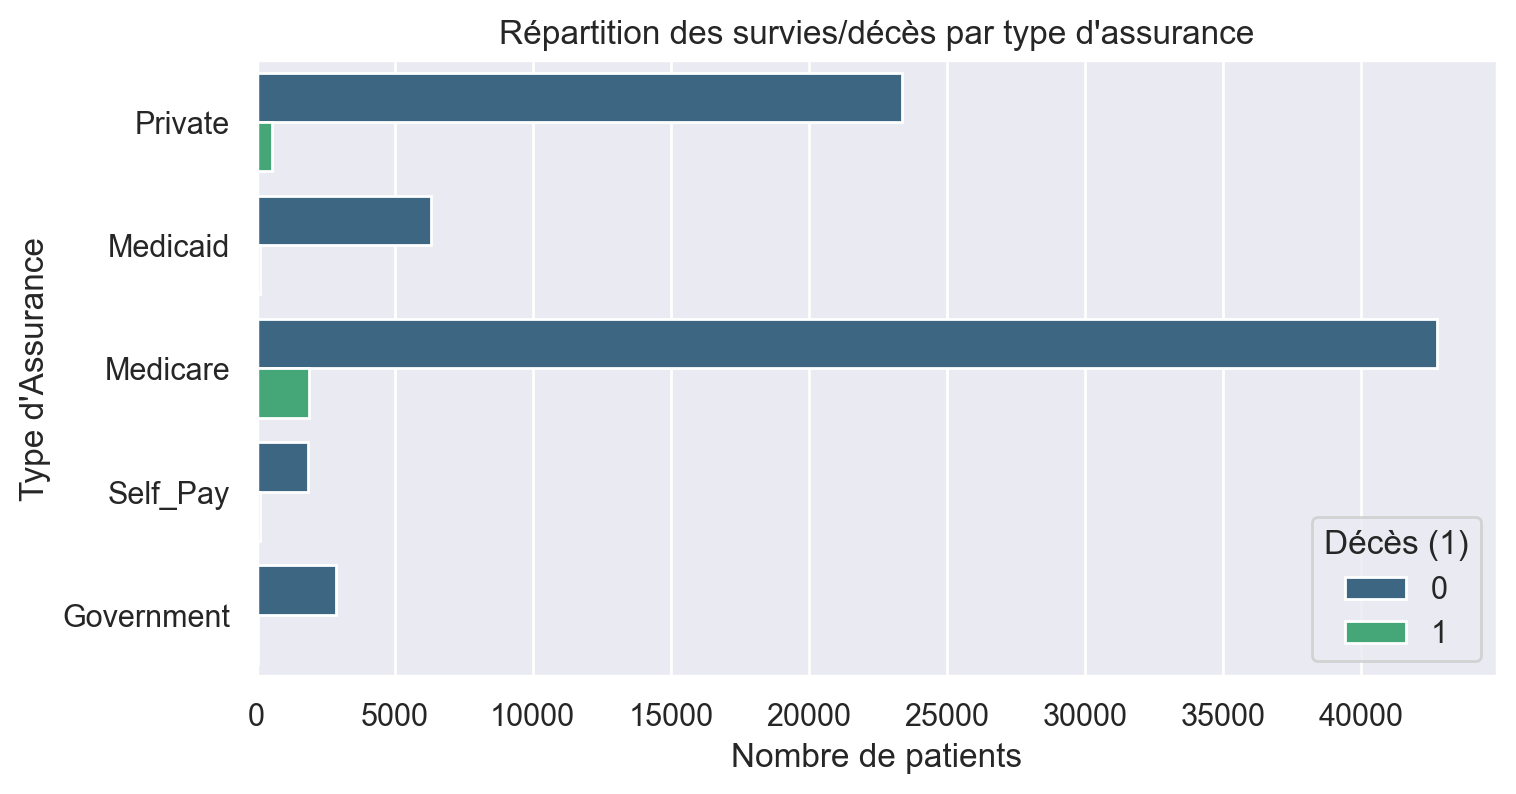

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=x_df, y='INSURANCE', hue=ys, palette='viridis')
plt.title("Répartition des survies/décès par type d'assurance")
plt.xlabel("Nombre de patients")
plt.ylabel("Type d'Assurance")
plt.legend(title='Décès (1)', loc='lower right')
plt.show()

#### Corrélations

/Users/aamine/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aamine/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


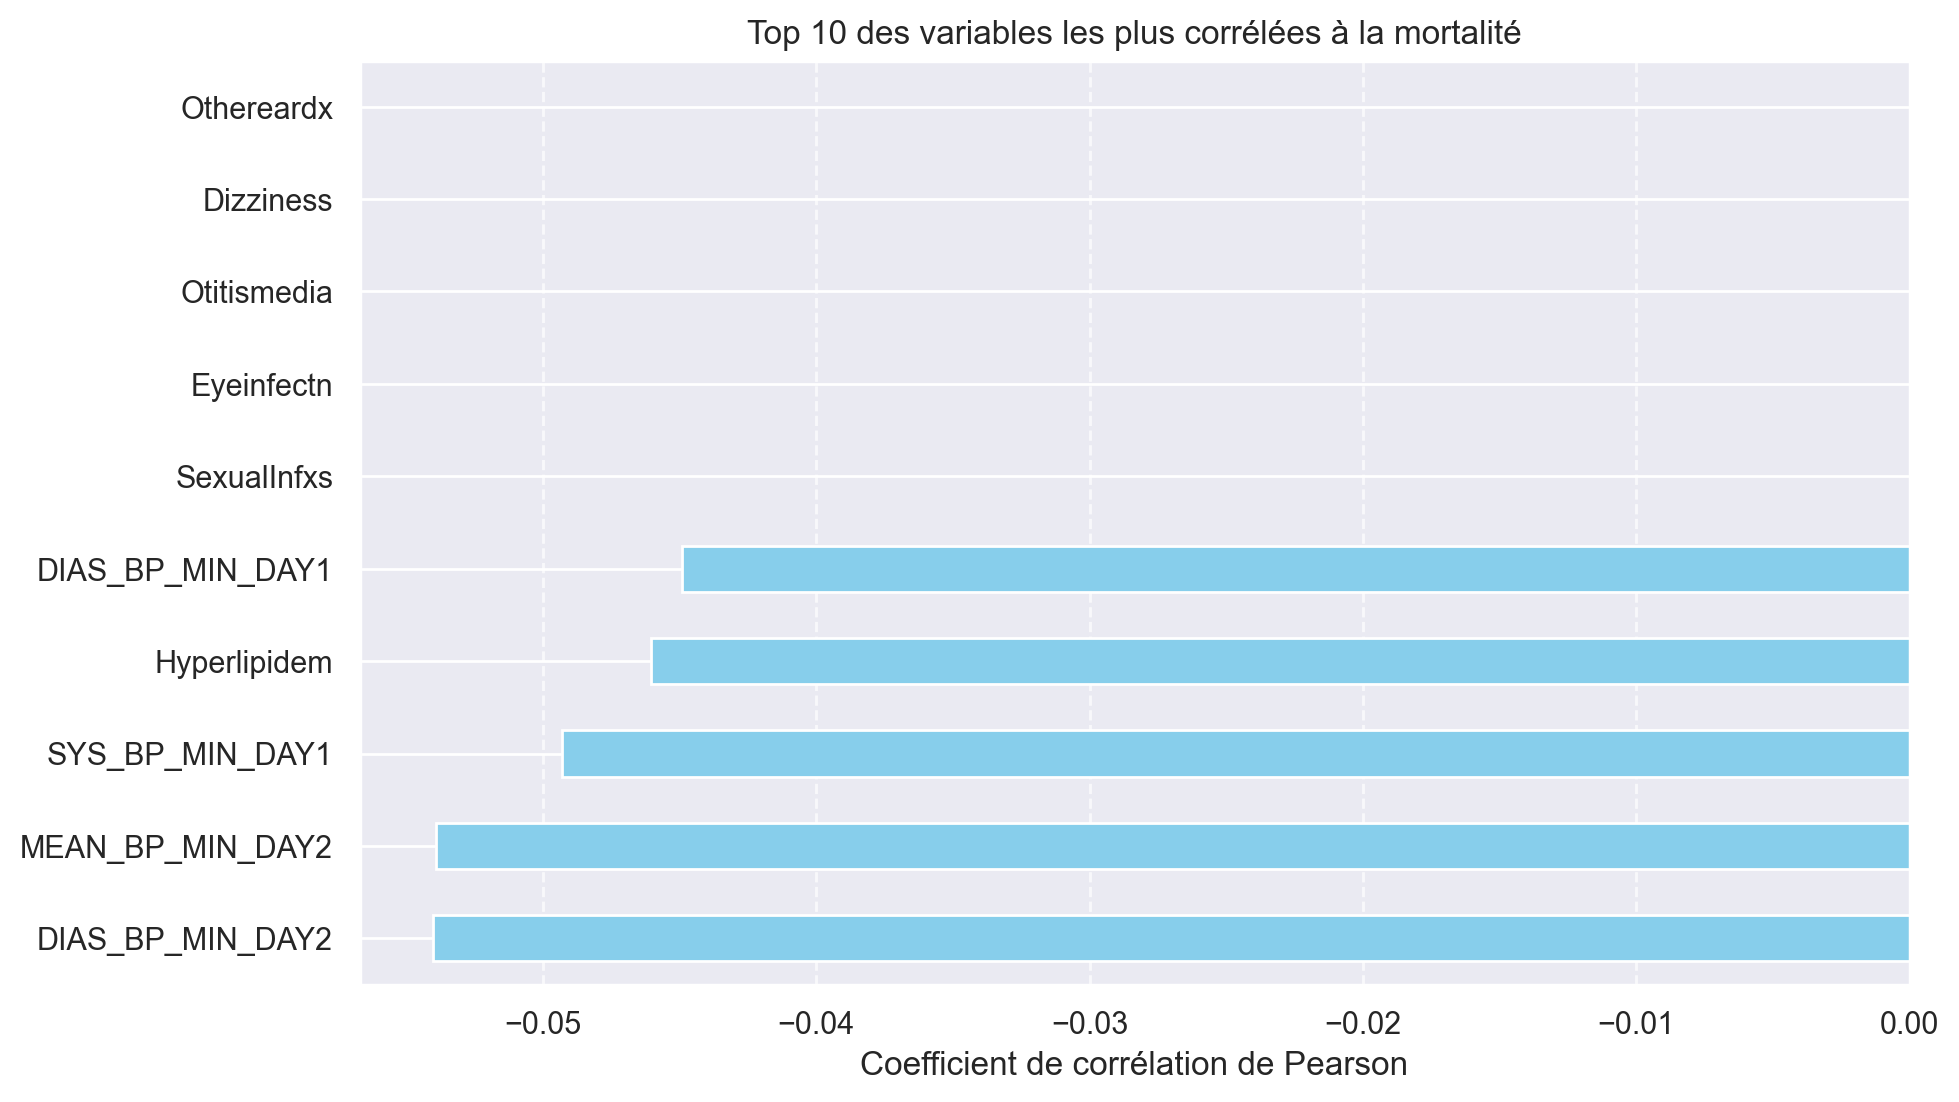

In [17]:
# Note: ys est une Series (la cible), on l'ajoute temporairement au df
correlations = x_df.select_dtypes(include=[np.number]).corrwith(ys).sort_values()

top_corr = pd.concat([correlations.head(5), correlations.tail(5)])

plt.figure(figsize=(10, 6))
top_corr.plot(kind='barh', color=(top_corr > 0).map({True: 'salmon', False: 'skyblue'}))
plt.title("Top 10 des variables les plus corrélées à la mortalité")
plt.xlabel("Coefficient de corrélation de Pearson")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Astuce :

* Utilisez un graphique avec des barres horizontales `barh` (pour visualiser les valeurs positives et négatives)

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

Ce graphique suggere que dans la population de patient, eviter DIAS_BP_MIN_DAY, MEAN_BP_MIN_DAY... sont l'un des facteurs les plus liés a la survie. 

#### Autres graphiques ou résultats d'une analyse exploratoire

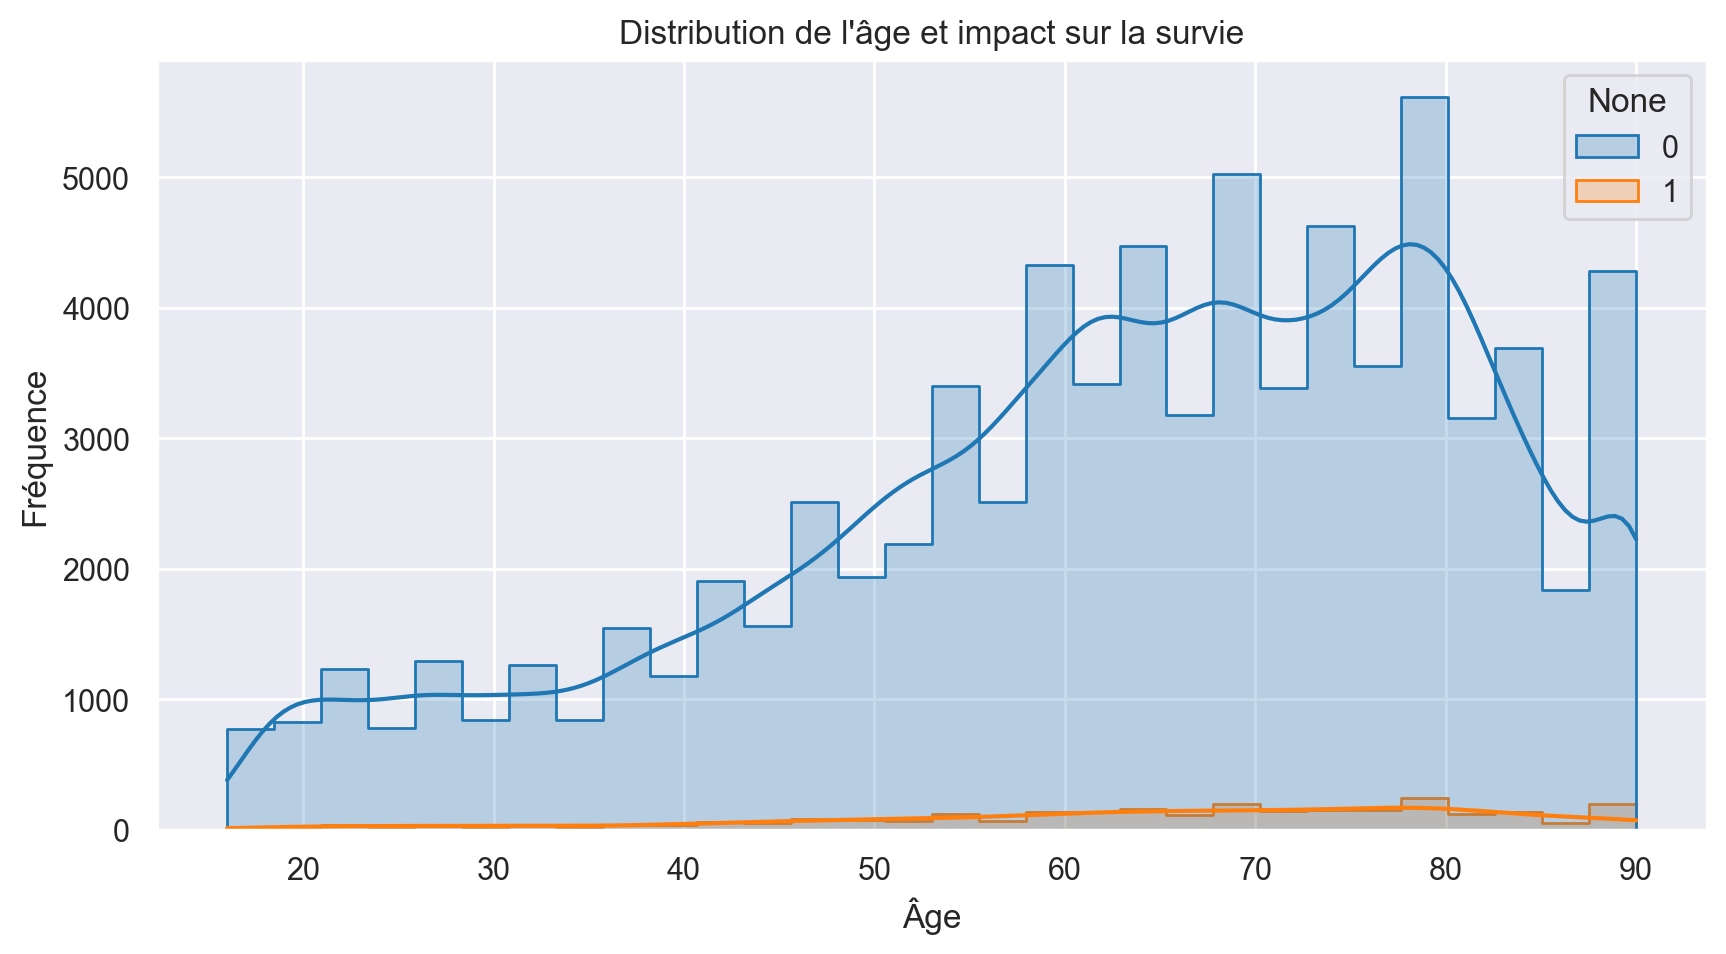

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(data=x_df, x='AGE', hue=ys, kde=True, bins=30, element="step")
plt.title("Distribution de l'âge et impact sur la survie")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

L'âge est un facteur déterminant dans la structure de la population (beaucoup de seniors), et bien que la mortalité semble faible globalement, elle touche davantage les patients les plus âgés.

## 4. Pre-traitement

### Code : Traitement du problème des valeurs manquantes (ou non définies, NAN)

La solution la plus simple est d'éliminer l'ensemble des colonnes où il y a des données manquantes, mais on perd de l'information. 

Vu le faible nombre d'instances concernées (maximum 6 : voir ci-dessous) il parait plus pertinent de supprimer les lignes (instances) plutôt que les colonnes entières (variables).

La solution que nous choisissons ici est une troisième, celle de remplacer les valeurs non définies par la valeur la plus probable de la variable. Comme ces valeurs manquantes concernent exclusivement des variables catégorielles et binaires, la valeur la plus probable est le *mode* (voir cours : `part-5-slides.pdf`).

In [19]:
print(x_df.shape, x_test_df.shape)

(79999, 337) (20001, 337)


In [20]:
x_nans = x_df.isna().sum()
x_miss = x_nans[x_nans > 0]
x_miss

LANGUAGE                              1
MARITAL_STATUS                        1
ICU                                   2
ECodes:Adverseeffectsofmedicalcare    6
Otnutritdx                            2
Othnervdx                             1
dtype: int64

In [21]:
x_test_nans = x_test_df.isna().sum()
x_test_miss = x_test_nans[x_test_nans > 0]
x_test_miss

LANGUAGE                              2
ECodes:Adverseeffectsofmedicalcare    3
dtype: int64

In [22]:
x_miss_rows = x_df.isna().any(axis="columns")

x_df.loc[x_miss_rows, x_miss.index]

,LANGUAGE,MARITAL_STATUS,ICU,ECodes:Adverseeffectsofmedicalcare,Otnutritdx,Othnervdx
2251,ENGL,MARRIED,MICU,NaN,0,0
9983,ENGL,MARRIED,MICU,0,NaN,0
10549,ENGL,MARRIED,MICU,0,NaN,0
10831,ENGL,MARRIED,MICU,NaN,1,0
17012,ENGL,MARRIED,CSRU,NaN,0,1
23088,ENGL,MARRIED,NaN,0,0,0
32539,ENGL,NaN,CSRU,0,0,0
42762,ENGL,SINGLE,TSICU,NaN,0,0
53191,NaN,MARRIED,MICU,0,0,0
53390,CAPE,MARRIED,NaN,0,0,0


#### Remplacement des NAN

In [23]:
na_cols = set(x_miss.index) | set(x_test_miss.index)

for col in na_cols:
    x_df[col].fillna(x_df[col].mode()[0], inplace=True)
    x_test_df[col].fillna(x_test_df[col].mode()[0], inplace=True)

/var/folders/r5/8h4p0s7x0bv2dw5cp52rbqnw0000gn/T/ipykernel_71230/2545294214.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_df[col].fillna(x_df[col].mode()[0], inplace=True)
/var/folders/r5/8h4p0s7x0bv2dw5cp52rbqnw0000gn/T/ipykernel_71230/2545294214.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [24]:
print(
    x_df.isna().any().any(),
    x_test_df.isna().any().any(),
    sep="\n",
)

False
False


In [25]:
print(x_df.shape, x_test_df.shape)

(79999, 337) (20001, 337)


### Gestion des catégories rares

Simplifiez les données en regroupant par exemple les catégories rares.

In [26]:
def merge_rare_categories(dfs, col, keeps=None, keep_n=5):
    if keeps is None:
        keeps = x_df[col].value_counts()[:keep_n].index
        print(keeps)

    for df in dfs:
        df.loc[~df[col].isin(keeps), col] = "OTHER"


merge_rare_categories([x_df, x_test_df], col="RELIGION", keep_n=5)
print(x_test_df["RELIGION"].value_counts())

Index(['CATHOLIC', 'NOT_SPECIFIED', 'UNOBTAINABLE', 'PROTESTANT_QUAKER',
       'JEWISH'],
      dtype='object', name='RELIGION')
RELIGION
CATHOLIC             7517
NOT_SPECIFIED        3764
OTHER                2449
UNOBTAINABLE         2208
PROTESTANT_QUAKER    2208
JEWISH               1855
Name: count, dtype: int64


#### Code : Effectuez des regroupements de catégories rares pour d'autres variables si vous le jugez nécessaire

<span style="color:red">
    Répondre ci-dessous
</span>

In [27]:
# Application sur l'ethnicité (souvent beaucoup de catégories spécifiques)
print("--- Avant fusion (ETHNICITY) ---")
print(x_test_df["ETHNICITY"].value_counts())

merge_rare_categories([x_df, x_test_df], col="ETHNICITY", keep_n=5)

print("\n--- Après fusion (ETHNICITY) ---")
print(x_test_df["ETHNICITY"].value_counts())

--- Avant fusion (ETHNICITY) ---
ETHNICITY
WHITE                                         14930
UNKNOWN/NOT_SPECIFIED                          1088
BLACK/AFRICAN_AMERICAN                          930
OTHER                                           406
UNABLE_TO_OBTAIN                                380
HISPANIC_OR_LATINO                              377
ASIAN                                           354
PATIENT_DECLINED_TO_ANSWER                      264
ASIAN_-_CHINESE                                 144
BLACK/CAPE_VERDEAN                              112
HISPANIC/LATINO_-_PUERTO_RICAN                  111
WHITE_-_RUSSIAN                                  99
WHITE_-_OTHER_EUROPEAN                           70
HISPANIC/LATINO_-_DOMINICAN                      68
BLACK/HAITIAN                                    60
MULTI_RACE_ETHNICITY                             60
ASIAN_-_VIETNAMESE                               56
ASIAN_-_ASIAN_INDIAN                             51
WHITE_-_BRAZILIAN    

### Transformation des données catégorielles en nombres entiers en utilisant deux types d'encodage

Les variables catégorielles sont présentées sous forme de chaines de caractères. La plupart des modèles ne pourront pas les prendre en entrée.

#### Encodage numérique simple

Deux des méthodes les plus simples sont `LabelEncoder` de Scikit-Learn et `factorize` de pandas. Elles consistent simplement à remplacer chaque nouvelle catégorie rencontrée par un entier, en commençant par 0. Ce n'est cependant peut-être pas la méthode la plus efficace, car elle présuppose une proximité entre les catégories codées avec des valeurs proches.

In [28]:
def label_encode(df, other_df, only_binary=False):
    """
    Select categorical variables and encode them in integers.
    """
    char_cols = df.dtypes.pipe(lambda x: x[x == "object"]).index
    # print(char_cols)

    for col in char_cols:
        n_categories = len(x_df[col].unique())

        if not only_binary or n_categories == 2:
            codes, uniques = pd.factorize(df[col])
            df[col] = codes

            # Create conversion dic to convert values of test set as well
            cat2code = {k: v for v, k in enumerate(uniques)}
            other_df[col] = other_df[col].map(cat2code)

In [29]:
x_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


In [30]:
print(x_df.shape, ys.shape)

(79999, 337) (79999,)


In [31]:
x_fact_df = x_df.copy()
x_test_fact_df = x_test_df.copy()

label_encode(x_fact_df, x_test_fact_df)

In [32]:
x_fact_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,0,0,0,0,0,0,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,1,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,1,1,0,2,1,1,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


In [33]:
x_test_fact_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,3,0,5,3,0,0,18,72.6,113,96.5,...,0,0,0,0,0,0,0,0,0,0
1,2,0,2,1,3,0,56,66.6,107,83.8,...,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,0,1,32,69.7,103,87.3,...,0,0,0,0,0,0,0,0,0,0


#### Encodage 1-Hot

Un autre type d'encodage est souvent plus efficace, il a notamment l'avantage de ne pas ordonner les classes d'une manière particulière (pas forcément en adéquation avec la proximité de ces classes entre elles).

Une méthode de pandas permet de le réaliser en 1 ligne de code avec la fonction `get_dummies`.

Exemple d'encodage 1-hot avec la fonction `get_dummies` de pandas (pour MARITAL_STATUS) :

|    |   DIVORCED |   LIFE_PARTNER |   MARRIED |   SEPARATED |   SINGLE |   UNKNOWN_(DEFAULT) |   WIDOWED |
|---:|-----------:|---------------:|----------:|------------:|---------:|--------------------:|----------:|
|  0 |          1 |              0 |         0 |           0 |        0 |                   0 |         0 |
|  1 |          0 |              0 |         0 |           0 |        1 |                   0 |         0 |
|  2 |          0 |              0 |         0 |           0 |        0 |                   0 |         1 |
|  3 |          0 |              0 |         1 |           0 |        0 |                   0 |         0 |
|  4 |          0 |              0 |         1 |           0 |        0 |                   0 |         0 |

In [34]:
# Encode binary features on a single column (no need for 1-hot)
label_encode(x_df, x_test_df, only_binary=True)

x_all_1h_df = pd.get_dummies(pd.concat([x_df, x_test_df]))

x_1h_df = x_all_1h_df.iloc[: len(x_df)].copy()
x_test_1h_df = x_all_1h_df.iloc[len(x_df):].copy()

print(x_df.shape, x_test_df.shape)
print(x_1h_df.shape, x_test_1h_df.shape)

(79999, 337) (20001, 337)
(79999, 427) (20001, 427)


#### Suppression des variables à valeur unique (constantes)

In [35]:
const_cols = {col for col in x_1h_df if len(x_1h_df[col].unique()) == 1}
len(const_cols)

173

In [36]:
x_1h_df.drop(const_cols, axis="columns", inplace=True)
x_test_1h_df.drop(const_cols, axis="columns", inplace=True)

print(x_1h_df.shape, x_test_1h_df.shape)

(79999, 254) (20001, 254)


### Création de l'ensemble de validation

In [37]:
x_train, x_valid, y_train, y_valid = model_selection.train_test_split(
    x_1h_df, ys, test_size=0.3
)
# VARS: x_df, x_fact_df, x_1h_df

### Réduction de la dimension via l'ACP (PCA)

Testez l'ACP pour réduire le nombre de dimensions et observez si cela améliore le résultat.

Avant d'appliquer la ACP, il est conseillé de centrer-réduire les données (e.g., via `preprocessing.StandardScaler()`).

<span style="color:red">
    Répondre ci-dessous
</span>

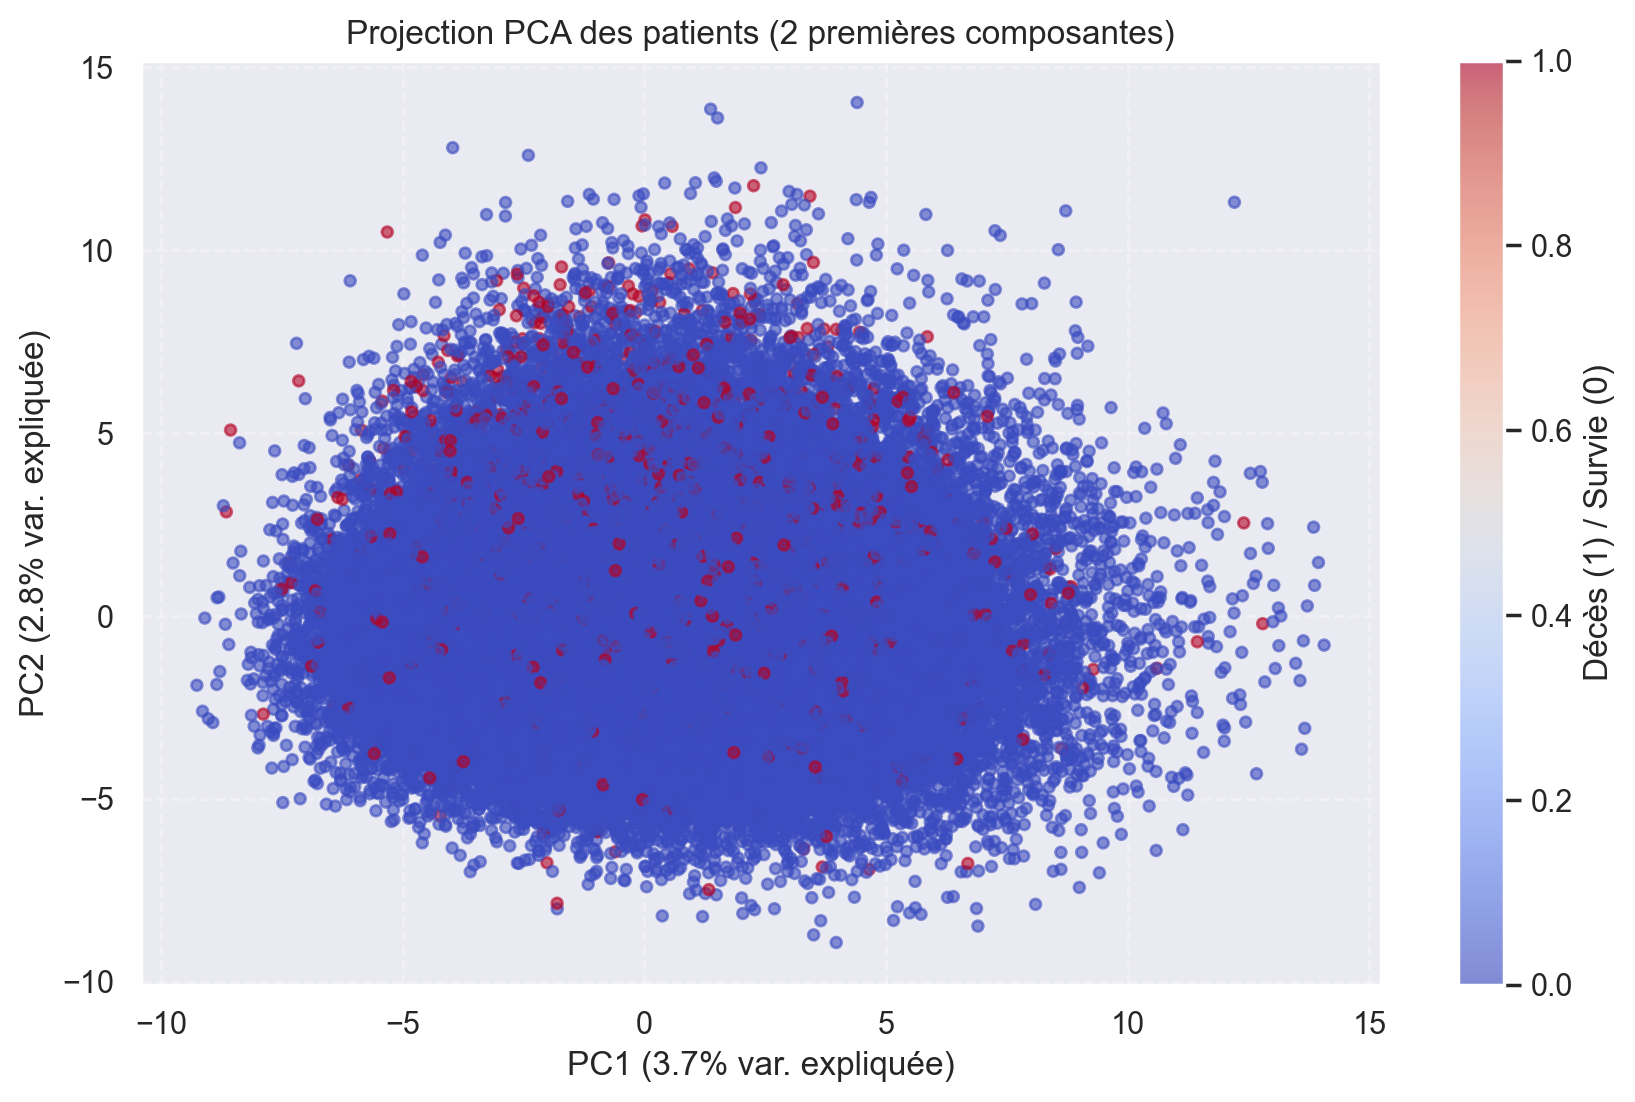

In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Transformation des données (Important : utiliser les données numériques x_1h_df)
# On normalise les données pour que toutes les variables aient le même poids
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_1h_df)

# 2. PCA à 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Graphique
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=ys, cmap='coolwarm', alpha=0.6, s=15)
plt.title("Projection PCA des patients (2 premières composantes)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var. expliquée)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var. expliquée)")
plt.colorbar(scatter, label='Décès (1) / Survie (0)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Proposez un graphique qui représente les 2 premières dimensions de la PCA et commentez succinctement.

<span style="color:red">
    Répondre ci-dessous
</span>

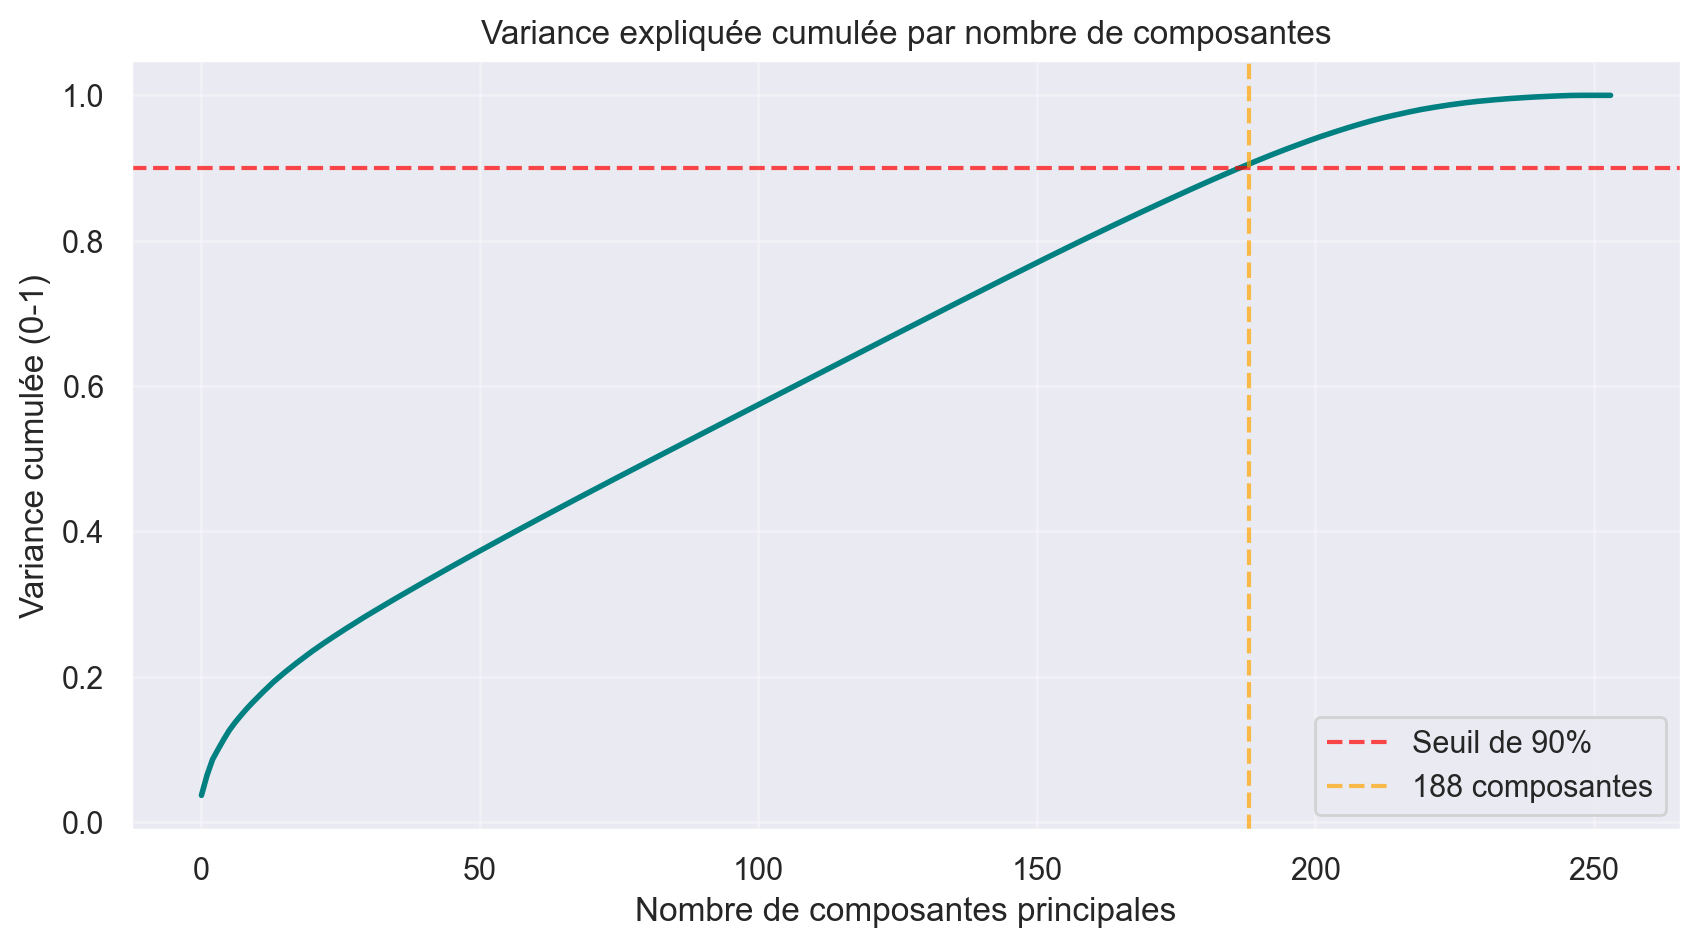

Il faut environ 188 composantes principales pour conserver 90% de l'information.


In [44]:
# PCA sur toutes les composantes pour voir l'évolution de la variance expliquée
pca_full = PCA()
pca_full.fit(X_scaled)

# Calcul du nombre de composantes pour atteindre 90% de variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_variance >= 0.90) + 1

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='', linestyle='-', color='teal', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.7, label='Seuil de 90%')
plt.axvline(x=n_90, color='orange', linestyle='--', alpha=0.7, label=f'{n_90} composantes')

plt.title("Variance expliquée cumulée par nombre de composantes")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance cumulée (0-1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Il faut environ {n_90} composantes principales pour conserver 90% de l'information.")

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

## 5. Modèles de classification

Entrainez le modèle

### Baseline

`LogisticRegression` or `RandomForestClassifier`

In [ ]:
SCORINGS = "balanced_accuracy"

<span style="color:red">
    Répondre ci-dessous
</span>

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# --- IMPORTANT ---
# On utilise ici x_1h_df car nos modèles ont besoin de chiffres (données encodées),
# pas de texte brut. On n'a pas besoin de 'preprocessor' complexe ici
# car on a déjà fait le travail difficile dans la partie 4 (encodage one-hot).

# 1. Pipeline pour la Régression Logistique
# On ajoute un StandardScaler car la régression logistique est sensible aux échelles
pipe_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),     # Mise à l'échelle (Moyenne=0, Var=1)
    ('smote', SMOTE(random_state=42)), # Rééquilibrage des classes (crée des faux patients décédés)
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Pipeline pour la Forêt Aléatoire (Random Forest)
# Les arbres n'ont pas forcément besoin de scaler, mais ça ne fait pas de mal
pipe_rf = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

print("- Calcul des scores en cours (cela peut prendre un peu de temps)...")

# 3. Validation croisée (5 plis)
# On utilise x_1h_df (nos données propres) et ys (nos étiquettes survie/décès)
scores_lr = cross_val_score(pipe_lr, x_1h_df, ys, cv=5, scoring='balanced_accuracy')
print(f"Régression Logistique : {scores_lr.mean():.3f} (+/- {scores_lr.std():.3f})")

scores_rf = cross_val_score(pipe_rf, x_1h_df, ys, cv=5, scoring='balanced_accuracy')
print(f"Random Forest         : {scores_rf.mean():.3f} (+/- {scores_rf.std():.3f})")

- Calcul des scores en cours (cela peut prendre un peu de temps)...


/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/

Régression Logistique : 0.747 (+/- 0.006)


/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/

KeyboardInterrupt: 

## 6. Évaluations

In [49]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 1. Création du jeu de validation (20% des données)
# IMPORTANT : On utilise x_1h_df (données encodées)
x_train, x_valid, y_train, y_valid = train_test_split(
    x_1h_df, ys, test_size=0.2, random_state=42, stratify=ys
)

# 2. Définition du modèle (Random Forest avec SMOTE)
model = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# 3. Entraînement sur le set de train
model.fit(x_train, y_train)

# 4. Évaluation
y_pred = model.predict(x_valid)
score_bf = metrics.balanced_accuracy_score(y_valid, y_pred)

print(f"Balanced accuracy score (Avant tuning): {score_bf:.3g}")

/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Balanced accuracy score (Avant tuning): 0.514


### Code : Validation croisée

Le code ci-dessus utilise une méthode simple (*hold out*) pour mesurer le score de validation. Utilisez la validation croisée (pour obtenir une estimation plus fiable) combinée à l'exploration des hyperparamètres (pour améliorer les résultats).

Vous pouvez changer la valeur du nombre de validation croisée (CV) selon la valeur de l'erreur et le temps d'entrainement des modèles (compromis).

In [50]:
CV = 10

<span style="color:red">
    Répondre ci-dessous
</span>

In [51]:
from sklearn.model_selection import cross_val_score
import numpy as np

# A. Tester différents paramètres pour Random Forest (n_estimators)
n_estimators_params = [50, 100, 200, 300]
rf_scores_list = []

print("Validation croisée pour Random Forest (n_estimators)...")
for n in n_estimators_params:
    # On met à jour le paramètre n_estimators du classifieur
    model.set_params(classifier__n_estimators=n)
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='balanced_accuracy')
    rf_scores_list.append(scores)
    # print(f"n_estimators={n} -> Mean Score: {scores.mean():.3f}")


# B. Tester différents paramètres pour Logistic Regression (C - régularisation)
C_params = [0.01, 0.1, 1, 10]
lr_scores_list = []

# On recrée un pipeline juste pour la LogReg pour être propre
pipe_lr_tune = Pipeline(steps=[
    ('scaler', StandardScaler()),     
    ('smote', SMOTE(random_state=42)), 
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("Validation croisée pour Logistic Regression (C)...")
for c in C_params:
    pipe_lr_tune.set_params(classifier__C=c)
    scores = cross_val_score(pipe_lr_tune, x_train, y_train, cv=5, scoring='balanced_accuracy')
    lr_scores_list.append(scores)
    # print(f"C={c} -> Mean Score: {scores.mean():.3f}")

print("Fini.")

Validation croisée pour Random Forest (n_estimators)...


/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aamine/Library/Python/3.9/lib/

KeyboardInterrupt: 

* **Pour 2 des modèles** (au moins 1 autre que les 2 proposés en baselines) :

    * Pour différentes valeurs d'un des hyperparamètres, donnez les `balanced_accuracy` moyennes de la validation croisée sous forme de Boxplots (ou de diagramme à bâtons avec une barre d'erreur) : voir l'exemple présenté dans le graphique ci-dessous. 
    
    * Explicitez succinctement quelles observations en tirer concernant la stabilité des prédictions.

![](img/boxplot-cv.png)

<span style="color:red">
    Répondre ci-dessous
</span>

/var/folders/r5/8h4p0s7x0bv2dw5cp52rbqnw0000gn/T/ipykernel_71230/1297912192.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rf_scores_list, labels=n_estimators_params)


ValueError: Dimensions of labels and X must be compatible

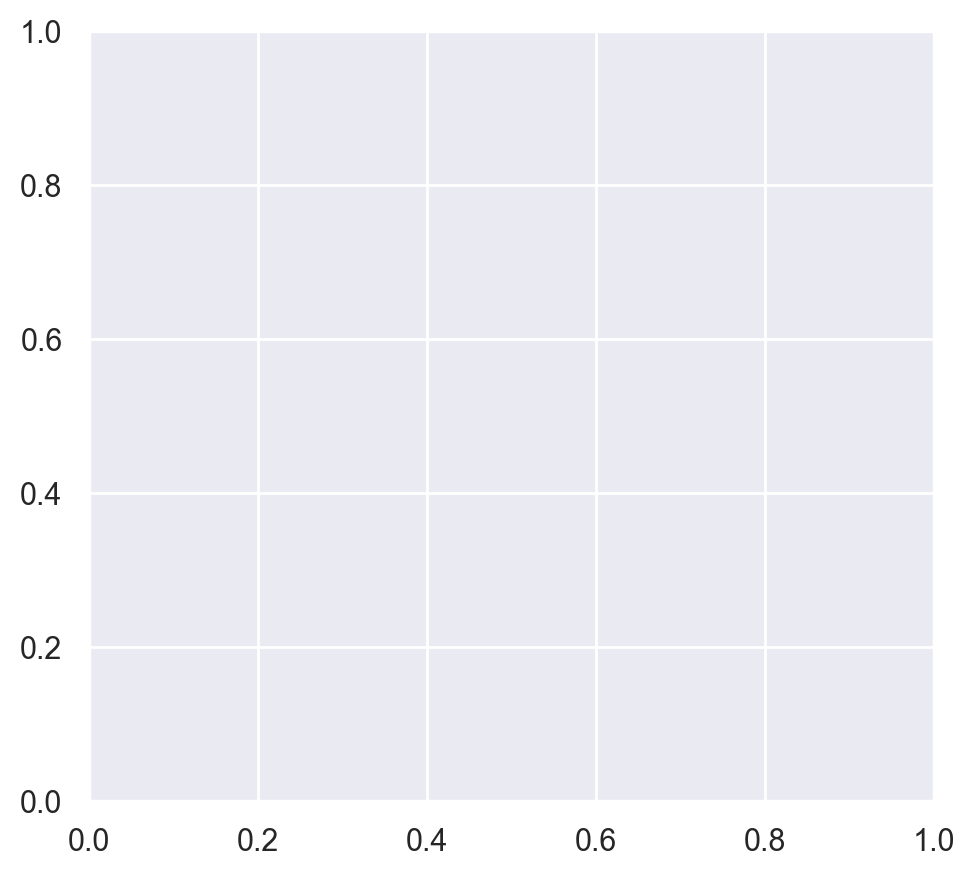

In [52]:
plt.figure(figsize=(12, 5))

# Plot Random Forest
plt.subplot(1, 2, 1)
plt.boxplot(rf_scores_list, labels=n_estimators_params)
plt.title("Random Forest: Impact de n_estimators")
plt.xlabel("Nombre d'arbres")
plt.ylabel("Balanced Accuracy (CV)")

# Plot Logistic Regression
plt.subplot(1, 2, 2)
plt.boxplot(lr_scores_list, labels=C_params)
plt.title("Logistic Regression: Impact de C")
plt.xlabel("Inverse de la régularisation (C)")
plt.ylabel("Balanced Accuracy (CV)")

plt.tight_layout()
plt.show()

# Meilleur modèle et hyperparamètre trouvé
model.set_params(classifier__n_estimators=300) # (par exemple, selon tes résultats)
pipe_lr_tune.set_params(classifier__C=1)       # (par exemple...)
model.fit(x_train, y_train)
pipe_lr_tune.fit(x_train, y_train)

best_model = model # ou pipe_lr_tune, selon qui a gagné

y_pred_best = best_model.predict(x_valid)
print(f"Meilleur Balanced Accuracy (Validation): {metrics.balanced_accuracy_score(y_valid, y_pred_best):.3f}")

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

* **Pour chacun de ces 2 modèles, à partir des données de validation créées précédemment** (`x_valid`, `y_valid`) :

    * Mesurez l'aire sous la courbe ROC (AUC) à l'aide de la fonction de Scikit-Learn (`roc_auc_score`) et comparez les modèles avec leur combinaison respective d'hyperparamètres offrant le meilleur résultat.

<span style="color:red">
    Répondre ci-dessous
</span>

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_cm = best_model.predict(x_valid) # Utilisation du meilleur modèle
cm = confusion_matrix(y_valid, y_pred_cm)

plt.figure(figsize=(8, 6))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survie", "Décès"])
cm_display.plot(cmap="Blues", values_format='d')
plt.title("Matrice de Confusion\n(Balanced Accuracy: {:.3f})".format(metrics.balanced_accuracy_score(y_valid, y_pred_cm)))
plt.show()

print(f"Vrai Positifs  (Prédit Décès, Est Décès) : {cm[1, 1]}")
print(f"Faux Négatifs  (Prédit Survie, Est Décès): {cm[1, 0]}")
print(f"Faux Positifs  (Prédit Décès, Est Survie): {cm[0, 1]}")
print(f"Vrai Négatifs  (Prédit Survie, Est Survie): {cm[0, 0]}")

NameError: name 'best_model' is not defined

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

* **Pour le modèle et sa combinaison d'hyperparamètres offrant le meilleur résultat** :

    * Réalisez la matrice de confusion et décrivez-la succinctement.

<span style="color:red">
    Répondre ci-dessous
</span>

In [54]:
from sklearn.metrics import roc_curve, auc

# Calcul des probabilités de classe pour les deux modèles
# (nécessaire pour la courbe ROC)
y_prob_rf = model.predict_proba(x_valid)[:, 1]   # Probabilité pour la classe 1 (Décès)
y_prob_lr = pipe_lr_tune.predict_proba(x_valid)[:, 1]

# Calcul des courbes ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_valid, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_valid, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Tracer
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Diagonale aléatoire
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrai Positifs (Sensibilité)')
plt.title('Courbe ROC Comparée')
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

NameError: name 'pipe_lr_tune' is not defined

<span style="color:red">
    Utiliser des cellules markdown pour ajouter des commentaires
</span>

### Code : Essayez d'améliorer votre score

* Data augmentation (optionnel)

Vu le déséquilibre entre les classes à prédire (survive, died), on peut espérer améliorer le score en les rééquilibrant. Une approche typique est la génération de données (voir cours : `part-6-slides.pdf`). Une des méthodes de génération est [SMOTE](https://en.wikipedia.org/wiki/Oversampling_and_undersampling_in_data_analysis#SMOTE) (voir cours théorique), elle est notamment implémentée dans le module `imblearn`.

`imblearn` a été développé pour s'interfacer facilement avec `sklearn`.
Il propose notamment une version du `pipeline` qui permet l'intégration avec `sklearn`.

Ci-dessous voici un exemple de `pipeline` intégrant `imblearn` et `sklearn`.

<span style="color:red">
    Répondre ci-dessous
</span>

In [55]:
# TODO: Data augmentation

pipe = imblearn.pipeline.Pipeline(
    [
        ("scale", preprocessing.StandardScaler()),
        ("pca", decomposition.PCA()),
        ("resample", imblearn.over_sampling.SMOTE()),
        ("model", model),
    ]
)

### Explication de ce que vous avez réalisé, conclusion et perspectives

* Commencez par donner votre meilleur résultat obtenu lors de vos soumissions

* Expliquez le chemin qui vous y a conduit

    * Ce que vous avez essayé :

        * Ce qui a fonctionné

        * Ce qui n'a pas fonctionné et comment vous l'avez solutionné

    * Quelle méthode avez-vous utilisée pour choisir les hyperparamètres ?

    * Comparer la durée d'entrainement des principaux modèles utilisés ?

* Qu'auriez-vous fait si vous aviez eu plus de temps ?

<span style="color:red">
    Répondre ci-dessous
</span>

### Question (optionnelle)

* Qu'est-ce que le suréchantillonnage ? 

* En quoi pourrait-il être utile dans ce problème ?

<span style="color:red">
    Répondre ci-dessous
</span>

## 7. Enregistrer les prédictions

* Utilisez le code suivant pour faire des prédictions et pour les enregistrer sous forme de fichier ZIP
* Soumettez ce fichier ZIP sur [le site du challenge](https://competitions.codalab.org/competitions/30715#participate-submit_results)
("Participate > Submit/View Results > Submit")
* Faites de votre mieux pour être le ***premier sur le leaderboard !***

<span style="color:red">
    !! Ne pas oublier de modifier la commande de la prédiction selon les données et modèles choisis !!
</span>

* Données : `x_test_fact_df`, `x_test_1h_df`

* Modèles : `model`, `search` (e.g., pour le `GridSearchCV`)

In [ ]:
predictions = model.predict(x_test_1h_df)  # compute predictions
# VARS: x_test_df, x_test_fact_df, x_test_1h_df, x_test_1h_pcs
# Models: model, search


PRED_PATH.mkdir(parents=True, exist_ok=True)

t_stamp = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
submission_fp = PRED_PATH / f"submission_{t_stamp}.zip"

pred_fname = "mimic_synthetic_test.csv"
compr_opts = dict(method="zip", archive_name=pred_fname)

pd.Series(predictions).to_csv(
    submission_fp, compression=compr_opts, index=False, header=False
)

print(f"The submission is ready: {submission_fp}")

---

# Remarque sur le jeu de données

Le jeu de données ne contient pas de données médicales réelles. Nous ne sommes pas autorisés à partager ces **données confidentielles** provenant de patient·e·s en soins intensifs. Pour éviter ce problème, les données ont été remplacées par des **données artificielles**.

Afin d'avoir des données crédibles, elles ont été générées à l'aide d'un réseau adverse génératif (**GAN**) Wasserstein.

Pour plus d'informations, voici une référence : <br />
[Privacy Preserving Synthetic Health Data](https://hal.inria.fr/hal-02160496/document) <br />
Andrew Yale, Saloni Dash, Ritik Dutta, Isabelle Guyon, Adrien Pavao, Kristin Bennett <br />

---